In [1]:
# preprocessing
import pandas as pd
import numpy as np

# missing value chart
import missingno

# graph
import matplotlib.pyplot as plt
import seaborn as sns

# sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore') 

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# ML - model
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# DL
from sklearn.neural_network import MLPClassifier


SEED = 22


In [11]:
df = pd.read_csv('data/data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35870 entries, 0 to 35869
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   children                           35870 non-null  int64  
 1   inc                                35870 non-null  float64
 2   age                                35870 non-null  float64
 3   employ_length                      35870 non-null  float64
 4   family                             35870 non-null  float64
 5   over30                             35870 non-null  int64  
 6   over60                             35870 non-null  int64  
 7   over90                             35870 non-null  int64  
 8   edu_Academic degree                35870 non-null  int64  
 9   edu_Higher education               35870 non-null  int64  
 10  edu_Incomplete higher              35870 non-null  int64  
 11  edu_Lower secondary                35870 non-null  int

In [12]:
X = df.drop(columns=['over30', 'over60', 'over90'])
y = df['over90']

In [13]:
from imblearn.over_sampling import SMOTE
sm_raw = SMOTE(sampling_strategy=0.1, random_state=SEED)
X, y = sm_raw.fit_resample(X, y)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=SEED)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((31304, 38), (7826, 38), (31304,), (7826,))

In [15]:
X.columns

Index(['children', 'inc', 'age', 'employ_length', 'family',
       'edu_Academic degree', 'edu_Higher education', 'edu_Incomplete higher',
       'edu_Lower secondary', 'edu_Secondary / secondary special',
       'marry_Civil marriage', 'marry_Married', 'marry_Separated',
       'marry_Single / not married', 'marry_Widow',
       'house_type_Co-op apartment', 'house_type_House / apartment',
       'house_type_Municipal apartment', 'house_type_Office apartment',
       'house_type_Rented apartment', 'house_type_With parents',
       'employment_Commercial associate', 'employment_Pensioner',
       'employment_State servant', 'employment_Student', 'employment_Working',
       'gender_F', 'gender_M', 'own_car_N', 'own_car_Y', 'own_house_N',
       'own_house_Y', 'own_workphone_0', 'own_workphone_1', 'own_phone_0',
       'own_phone_1', 'own_email_0', 'own_email_1'],
      dtype='object')

In [16]:
### train set - SMOTE

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state= SEED)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

In [17]:
X_resampled.shape, len(y_resampled)

((56916, 38), 56916)

In [18]:
y_test.value_counts()

over90
0    7115
1     711
Name: count, dtype: int64

In [19]:
y_resampled.value_counts()

over90
0    28458
1    28458
Name: count, dtype: int64

In [37]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

classifiers = {
    'sgd': SGDClassifier(random_state=SEED, loss='perceptron'),
    'logistic_regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'support_vector_machine': SVC(random_state=SEED, probability=True),
    'decision_tree': DecisionTreeClassifier(random_state=SEED),
    'random_forest': RandomForestClassifier(random_state=SEED),
    'gaussian_naive_bayes': GaussianNB(),
    'k_nearest_neighbors': KNeighborsClassifier(),
    'gradient_boosting': GradientBoostingClassifier(random_state=SEED),
    'xgb': XGBClassifier(random_state=SEED),
    'lightb': LGBMClassifier(random_state=SEED),
    'cat': CatBoostClassifier(random_state=SEED)
}

In [26]:
# from sklearn.metrics import f1_score
# from sklearn.model_selection import train_test_split

# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import cross_val_score


# from imblearn.over_sampling import SMOTE


# def run_classifiers(classifiers, X, y, cv=5):
#     results = {}
#     for name, clf in classifiers.items():
#         pipeline = Pipeline([
#             ('scaler', StandardScaler()),
#             ('classifier', clf)
#         ])
        
#         # 교차 검증을 통한 평가
#         scores = cross_val_score(pipeline, X, y, cv=cv)
#         results[name] = {'CV_mean': scores.mean(), 'CV_std': scores.std()}
        
#         # 테스트 데이터를 분리하여 평가
#         X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
#         sm = SMOTE(random_state= SEED)
#         X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
#         pipeline.fit(X_resampled, y_resampled)
#         y_pred = pipeline.predict(X_test)
#         test_f1 = f1_score(y_test, y_pred, average='weighted')
        
#         results[name]['test_score'] = pipeline.score(X_test, y_test)
#         results[name]['F1_score'] = test_f1
        
#         print(name)
#         print(f"{name}: CV Mean: {scores.mean()} (+/- {scores.std() * 2})")
#         print(f'Test F1 Score: {test_f1}')
#         print(f'{pipeline.score(X_test, y_test)}' )

#     return results



In [27]:
# results = run_classifiers(classifiers, X, y)

sgd
sgd: CV Mean: 0.95627395859954 (+/- 0.043562745192325024)
Test F1 Score: 0.8588820600220339
0.8301814464605163
logistic_regression
logistic_regression: CV Mean: 0.9739074878609764 (+/- 0.023177554423361987)
Test F1 Score: 0.9575875521203717
0.9588550983899821
support_vector_machine
support_vector_machine: CV Mean: 0.9802197802197803 (+/- 0.020899239928421978)
Test F1 Score: 0.9648513704973415
0.9634551495016611
decision_tree
decision_tree: CV Mean: 0.9549706107845642 (+/- 0.010310886590482368)
Test F1 Score: 0.9885494139808387
0.9884998722208025
random_forest
random_forest: CV Mean: 0.9808331203680041 (+/- 0.011287467830067769)
Test F1 Score: 0.9910442919253849
0.9910554561717353
gaussian_naive_bayes
gaussian_naive_bayes: CV Mean: 0.23365704063378484 (+/- 0.017141549584922748)
Test F1 Score: 0.2671735863467409
0.23511372348581652
k_nearest_neighbors
k_nearest_neighbors: CV Mean: 0.9723485816509072 (+/- 0.018601140414031686)
Test F1 Score: 0.9880036542992452
0.9879887554306159
gradi

In [60]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

classifiers = {
    # 'sgd': SGDClassifier(random_state=SEED, loss='perceptron'),
    'logistic_regression': LogisticRegression(random_state=SEED, max_iter=1000),
    # 'support_vector_machine': SVC(random_state=SEED, probability=True),
    # 'decision_tree': DecisionTreeClassifier(random_state=SEED),
     'random_forest': RandomForestClassifier(random_state=SEED),
    # 'gaussian_naive_bayes': GaussianNB(),
    # 'k_nearest_neighbors': KNeighborsClassifier(),
    # 'gradient_boosting': GradientBoostingClassifier(random_state=SEED),
    'xgb': XGBClassifier(random_state=SEED),
    # 'lightb': LGBMClassifier(random_state=SEED),
    # 'cat': CatBoostClassifier(random_state=SEED)
}

In [61]:
from sklearn.model_selection import GridSearchCV

# 각 분류기에 대한 파라미터 그리드 설정
param_grids = {
    'sgd': {
        'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
        'classifier__penalty': ['l2', 'l1', 'elasticnet'],
        'classifier__loss': ['hinge', 'log', 'modified_huber']
    },
    'logistic_regression': {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2', 'l1']
    },
    'support_vector_machine': {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__kernel': ['linear', 'rbf']
    },
    'decision_tree': {
        'classifier__max_depth': [None, 10, 20, 30, 40],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'random_forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'gaussian_naive_bayes': {},
    'k_nearest_neighbors': {
        'classifier__n_neighbors': [3, 5, 10],
        'classifier__weights': ['uniform', 'distance'],
        'classifier__metric': ['euclidean', 'manhattan']
    },
    'gradient_boosting': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.1, 1.0],
        'classifier__max_depth': [3, 5, 7],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'xgb': {
        'classifier__learning_rate': [0.01, 0.1, 1.0],
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [3, 5, 7]},
    'lightb': {
        'classifier__learning_rate': [0.01, 0.1, 1.0],
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [3, 5, 7]},
    'cat': {
        'classifier__learning_rate': [0.01, 0.1, 1.0],
        'classifier__iterations': [100, 200, 300],
        'classifier__depth': [3, 5, 7]
    } 
}

# GridSearchCV를 사용하여 최적의 하이퍼파라미터 찾기


In [74]:
from sklearn.metrics import f1_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

def model_test(classifiers, X, y, param_grids, cv=5):
    results = {}
    for name, clf in classifiers.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', clf)
        ])
        
        # 그리드 서치를 통해 최적의 파라미터 찾기
        
        param_grid = param_grids[name]
        grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_weighted')
        grid_search.fit(X, y)
        
        # 최적의 파라미터로 모델 재구성
        best_estimator = grid_search.best_estimator_
        
        
        # 교차 검증을 통한 평가
        scores = cross_val_score(best_estimator, X, y, cv=cv)
        results[name] = {'CV_mean': scores.mean(), 'CV_std': scores.std()}
        
        # 테스트 데이터를 분리하여 평가
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
        sm = SMOTE(random_state=SEED)
        X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
        best_estimator.fit(X_resampled, y_resampled)
        y_pred = best_estimator.predict(X_test)
        test_f1 = f1_score(y_test, y_pred, average='weighted')
        
        results[name]['test_score'] = best_estimator.score(X_test, y_test)
        results[name]['F1_score'] = test_f1
        results[name]['best_param'] = grid_search.best_params_

           # ROC 커브를 그리기 위해 확률 예측
        y_probs = best_estimator.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)
        
        # ROC 커브를 그림
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve')
        plt.legend(loc="lower right")
        plt.show()
        
        print(name)
        print(f"{name}: CV Mean: {scores.mean()} (+/- {scores.std() * 2})")
        print(f'Test F1 Score: {test_f1}')
        print(f'{best_estimator.score(X_test, y_test)}' )
        

    return results

In [63]:
results = model_test(classifiers, X, y, param_grids)

KeyError: 'logistic_regression'

In [58]:
pd.DataFrame(results)

""


In [59]:
results

{}

In [64]:
from sklearn.model_selection import GridSearchCV

# 각 분류기에 대한 파라미터 그리드 설정
param_grids = {
    
    'logistic_regression': {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2', 'l1']
    },


    'random_forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },


    'xgb': {
        'classifier__learning_rate': [0.01, 0.1, 1.0],
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [3, 5, 7]}
    } 


In [79]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

classifiers = {
    # 'sgd': SGDClassifier(random_state=SEED, loss='perceptron'),
    'logistic_regression': LogisticRegression(random_state=SEED, max_iter=1000),
    # 'support_vector_machine': SVC(random_state=SEED, probability=True),
    # 'decision_tree': DecisionTreeClassifier(random_state=SEED),
    # 'random_forest': RandomForestClassifier(random_state=SEED),
    # 'gaussian_naive_bayes': GaussianNB(),
    # 'k_nearest_neighbors': KNeighborsClassifier(),
    # 'gradient_boosting': GradientBoostingClassifier(random_state=SEED),
    'xgb': XGBClassifier(random_state=SEED),
    # 'lightb': LGBMClassifier(random_state=SEED),
    # 'cat': CatBoostClassifier(random_state=SEED)
}

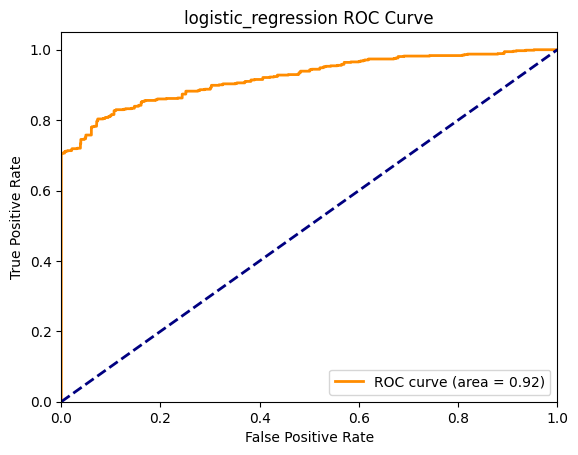

logistic_regression
logistic_regression: CV Mean: 0.9739074878609764 (+/- 0.023177554423361987)
Test F1 Score: 0.9575875521203717
0.9588550983899821


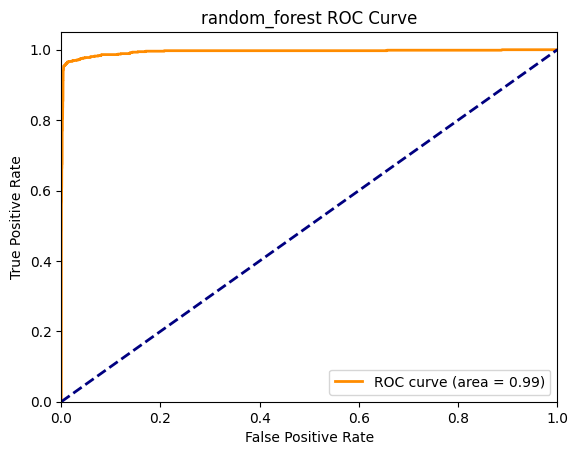

random_forest
random_forest: CV Mean: 0.9877331970355225 (+/- 0.016461611073384192)
Test F1 Score: 0.9911749882403681
0.9911832353692819


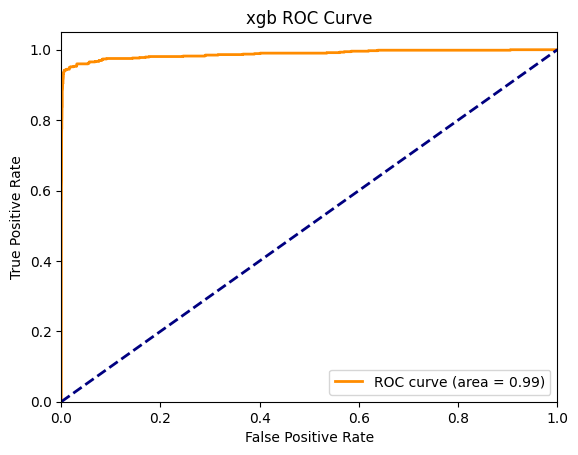

xgb
xgb: CV Mean: 0.9853565039611549 (+/- 0.018957954948997786)
Test F1 Score: 0.9893711064256188
0.9893943266036289


In [75]:
results = model_test(classifiers, X, y, param_grids)

In [73]:
results

{}

In [78]:
pd.DataFrame(results).T

,CV_mean,CV_std,test_score,F1_score,best_param
logistic_regression,0.973907,0.011589,0.958855,0.957588,"{'classifier__C': 1, 'classifier__penalty': 'l2'}"
random_forest,0.987733,0.008231,0.991183,0.991175,"{'classifier__max_depth': 30, 'classifier__min..."
xgb,0.985357,0.009479,0.989394,0.989371,"{'classifier__learning_rate': 0.1, 'classifier..."


In [83]:
from sklearn.metrics import f1_score, roc_curve, auc, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

def model_test(classifiers, X, y, param_grids, cv=5):
    results = {}
    for name, clf in classifiers.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', clf)
        ])
        
        # 그리드 서치를 통해 최적의 파라미터 찾기
        
        param_grid = param_grids[name]
        grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_weighted')
        grid_search.fit(X, y)
        
        # 최적의 파라미터로 모델 재구성
        best_estimator = grid_search.best_estimator_
        results[name] = {'best_param': grid_search.best_params_}
        
        # 교차 검증을 통한 평가
        scores = cross_val_score(best_estimator, X, y, cv=cv, scoring='f1_weighted')
        results[name]['CV_mean'] = scores.mean()
        results[name]['CV_std'] = scores.std()
        
        # 테스트 데이터를 분리하여 평가
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
        sm = SMOTE(random_state=SEED)
        X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
        best_estimator.fit(X_resampled, y_resampled)
        y_pred = best_estimator.predict(X_test)
        test_f1 = f1_score(y_test, y_pred, average='weighted')
        test_precision = precision_score(y_test, y_pred, average='weighted')
        test_recall = recall_score(y_test, y_pred, average='weighted')
        
        results[name]['test_score'] = best_estimator.score(X_test, y_test)
        results[name]['F1_score'] = test_f1
        results[name]['Precision'] = test_precision
        results[name]['Recall'] = test_recall
        
        # ROC 커브를 그리기 위해 확률 예측
        y_probs = best_estimator.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)
        
        # ROC 커브를 그림
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve')
        plt.legend(loc="lower right")
        plt.show()

        results[name]['AUC'] = roc_auc
        
        print(name)
        print(f"{name}: CV Mean: {scores.mean()} (+/- {scores.std() * 2})")
        print(f'Test F1 Score: {test_f1}')
        print(f'Test Precision: {test_precision}')
        print(f'Test Recall: {test_recall}')
        print(f'{best_estimator.score(X_test, y_test)}' )

    return results

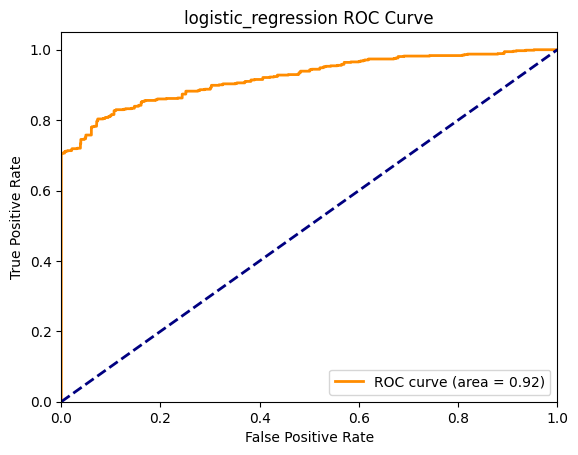

logistic_regression
logistic_regression: CV Mean: 0.9712749736854821 (+/- 0.02902993479649336)
Test F1 Score: 0.9575875521203717
Test Precision: 0.9570473830140053
Test Recall: 0.9588550983899821
0.9588550983899821


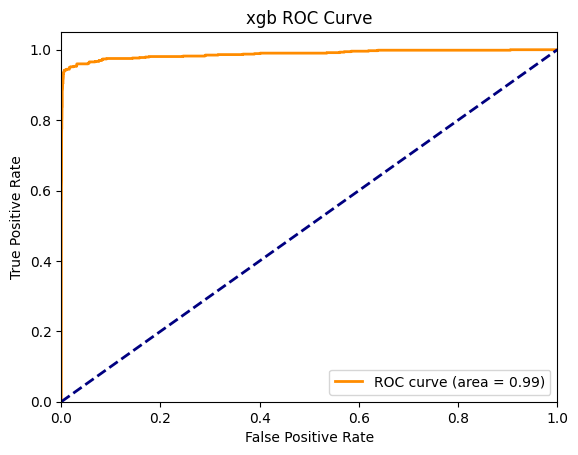

xgb
xgb: CV Mean: 0.9847980041453868 (+/- 0.021006823210705648)
Test F1 Score: 0.9893711064256188
Test Precision: 0.9893524494754818
Test Recall: 0.9893943266036289
0.9893943266036289


In [84]:
results = model_test(classifiers, X, y, param_grids)



In [86]:
model_result = pd.DataFrame(results).T
model_result

,best_param,CV_mean,CV_std,test_score,F1_score,Precision,Recall,AUC
logistic_regression,"{'classifier__C': 1, 'classifier__penalty': 'l2'}",0.971275,0.014515,0.958855,0.957588,0.957047,0.958855,0.920207
xgb,"{'classifier__learning_rate': 0.1, 'classifier...",0.984798,0.010503,0.989394,0.989371,0.989352,0.989394,0.987822
